<a href="https://colab.research.google.com/github/Yash-k10/pattern_recognition/blob/main/practical6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (200, 28, 28)
Testing Images : (200, 28, 28)


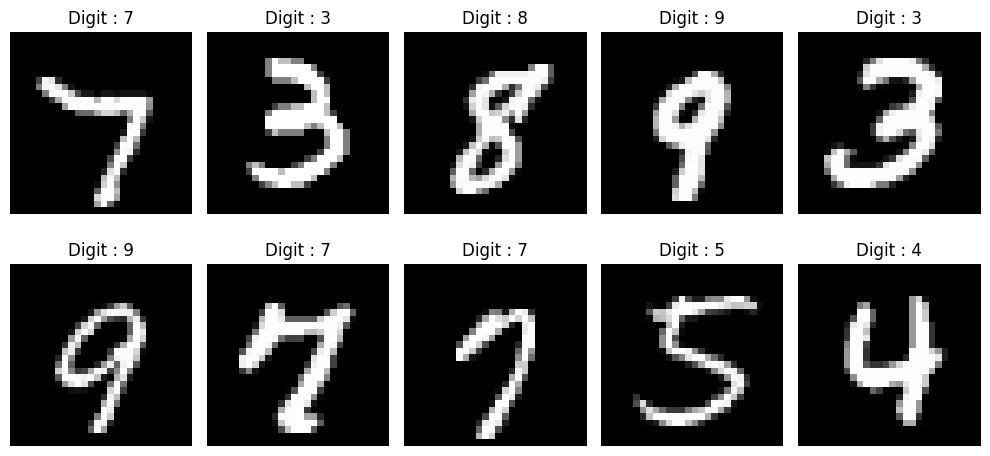


Extracting Features...
Feature Extraction Completed

Training SVM...
Training Completed

Recognition Accuracy : 93.00%

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.97      1.00      0.98        28
           2       0.90      1.00      0.95        19
           3       0.93      0.93      0.93        14
           4       0.95      1.00      0.97        19
           5       0.94      0.83      0.88        18
           6       1.00      0.87      0.93        15
           7       0.95      0.86      0.90        22
           8       0.79      0.95      0.86        20
           9       1.00      0.83      0.90        23

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.94      0.93      0.93       200



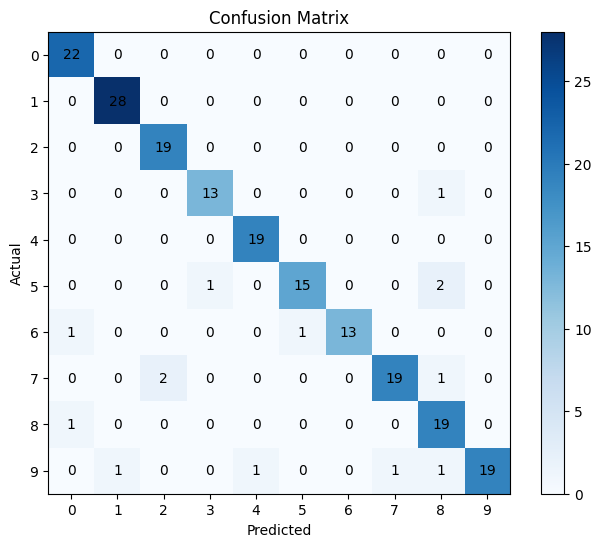

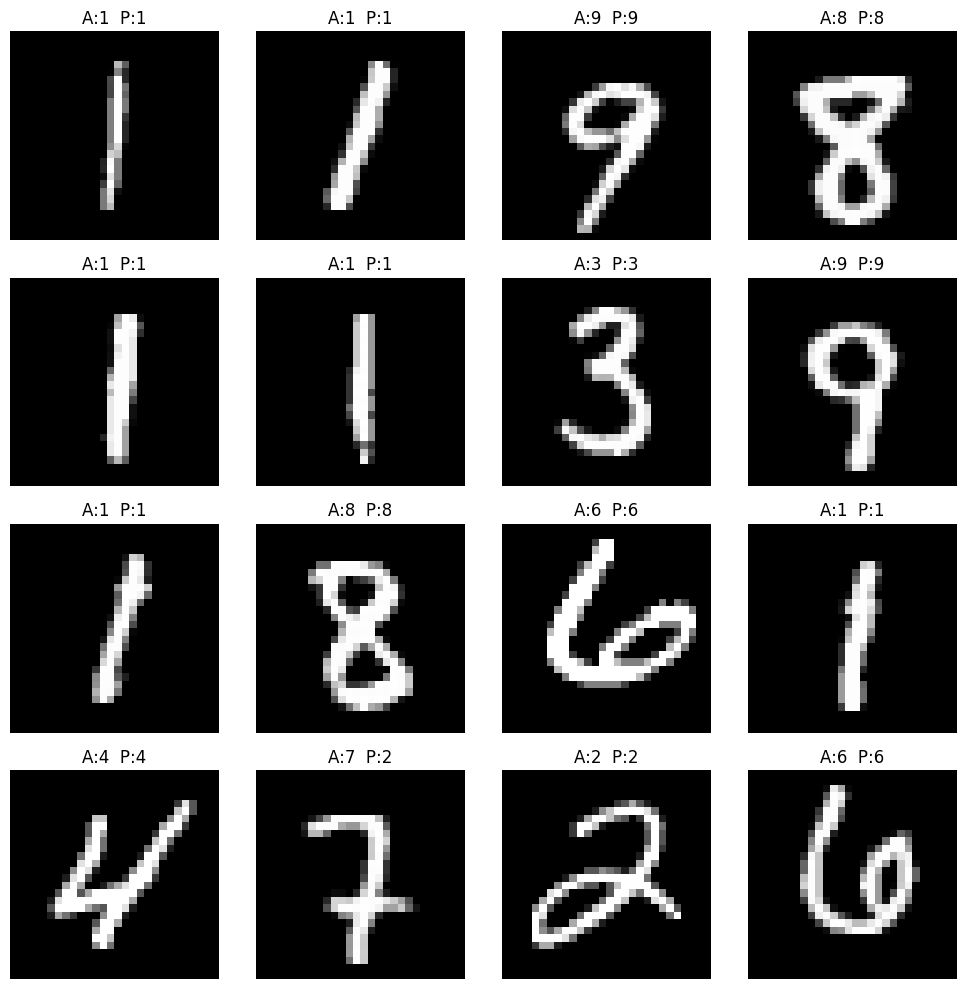


Dataset Used        : MNIST
Training Samples    : 200
Testing Samples     : 200
Feature Extraction  : HOG + Hu Moments
Classifier          : Support Vector Machine (SVM)
Recognition Accuracy: 93.00%


In [1]:
# ============================================================
# Practical:
# Postal Code Recognition using Structural Pattern
# Representation and Classification Techniques
# Dataset: MNIST (200 Random Samples)
# ============================================================

# Install required library (Run only once)
!pip install -q scikit-image

# ============================================================
# Import Libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.datasets import mnist

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Load MNIST Dataset
# ============================================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# ============================================================
# Select 200 Random Images
# ============================================================

np.random.seed(42)      # Same random samples every run

train_index = np.random.choice(len(X_train), 200, replace=False)
test_index = np.random.choice(len(X_test), 200, replace=False)

X_train = X_train[train_index]
y_train = y_train[train_index]

X_test = X_test[test_index]
y_test = y_test[test_index]

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

# ============================================================
# Display Sample Images
# ============================================================

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Digit : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Feature Extraction
# Structural Pattern Representation
# (HOG + Hu Moments)
# ============================================================

def extract_features(image):

    image = image.astype(np.uint8)

    # HOG Features
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(7,7),
        cells_per_block=(2,2),
        feature_vector=True
    )

    # Binary Image
    _, binary = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Hu Moments
    hu = cv2.HuMoments(cv2.moments(binary)).flatten()

    # Combine Features
    features = np.concatenate((hog_features, hu))

    return features

# ============================================================
# Extract Features
# ============================================================

print("\nExtracting Features...")

X_train_features = np.array([extract_features(img) for img in X_train])

X_test_features = np.array([extract_features(img) for img in X_test])

print("Feature Extraction Completed")

# ============================================================
# Train SVM Classifier
# ============================================================

print("\nTraining SVM...")

model = SVC(kernel='rbf', gamma='scale')

model.fit(X_train_features, y_train)

print("Training Completed")

# ============================================================
# Prediction
# ============================================================

y_pred = model.predict(X_test_features)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nRecognition Accuracy : {:.2f}%".format(accuracy*100))

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='black')

plt.show()

# ============================================================
# Display Predictions
# ============================================================

plt.figure(figsize=(10,10))

random_images = np.random.choice(len(X_test), 16, replace=False)

for i, index in enumerate(random_images):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[index], cmap='gray')

    plt.title(f"A:{y_test[index]}  P:{y_pred[index]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Final Result
# ============================================================

print("\n===================================")
print("Dataset Used        : MNIST")
print("Training Samples    :", len(X_train))
print("Testing Samples     :", len(X_test))
print("Feature Extraction  : HOG + Hu Moments")
print("Classifier          : Support Vector Machine (SVM)")
print("Recognition Accuracy: {:.2f}%".format(accuracy*100))
print("===================================")